ML Third Assignment
<br>
Name: Negar Fathi
<br>
Student ID: 400222069

In [1]:
pip install hazm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.6/892.6 kB 11.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 43.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 35.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.0/235.0 kB 23.6 MB/s eta 0:00:00
  Created wheel for flashtext: filename=flashtext-2.7-py2.py3-none-any.whl size=9296 sha256=ac573cd4eaff62e318079a5d97a1d3292f70dde4fb96da779aa28936996d8218
  Stored in directory: /root/.cache/pip/wheels/bc/be/39/c37ad168eb2ff644c9685f52554440372129450f0b8ed203dd
Successfully built flashtext
  Attempting uninstall: numpy
    Found existing installation: numpy 1.25.2
    Uninstalling numpy-1.25.2:
      Successfully uninstalled numpy-1.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. Thi

In [1]:
import numpy as np
import pandas as pd
import re
from collections import Counter
from hazm import Normalizer, Lemmatizer, Stemmer, WordTokenizer
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import class_weight
from wordcloud import STOPWORDS
import xgboost as xgb
import seaborn as sns
import joblib

1. Data preprocessing

read the training data:

In [3]:
df_train = pd.read_excel('/content/train_data.xlsx', names=['text', 'emotion'])
df_train.to_csv('/content/data.csv', index=False)

read the test data:

In [55]:
df_test = pd.read_csv('/content/3rdHW_test.csv', names=['X'])
df_test.to_csv('/content/test_data', index=False)

load and inspect data:

In [56]:
df_train = pd.read_csv('/content/data.csv')
df_test = pd.read_csv('/content/test_data')

In [6]:
df_test.head(10)

,text
0,صعب روزی، بوالعجب کاری، پریشان عالمی
1,بسیار نرم و لطیف بوده و کیفیت بالایی داره.
2,اصلا رنگش با چیزی که تو عکس بود خیلی فرق داشت
3,خیلی زیبا و ب اندازه و با دقت طراحی شده
4,سبزی پلو با ماهی مال عید نوروزه، امشب سوشی میخ...
5,لج بازیو بذار کنار یه فرصت دیگه بهت میدم
6,بیا چندتا سیل جمعیت نشونت بدم تا دفعه بعدی به...
7,دلم میخواد زیبا باشم و دوست داشته بشم:(
8,عباس علی‌زاده معروف به «بروس‌لی افغانستان» وار...
9,امشب راحت میتوان به این موضوع پی برد مگه نه؟


In [7]:
df_train.shape

(4923, 2)

In [8]:
df_train.head(50)

,text,emotion
0,عکسی که چند روز پیش گذاشته بودم این فیلم الانش...,OTHER
1,تنهاییم شبیه تنهاییه ظهرای بچگیم شده وقتی که ه...,SAD
2,خوبه تمام قسمت‌های گوشی رو محافظت می‌کنه,HAPPY
3,این خاک مال مردمان است نه حاکمان #ایران #مهسا_...,ANGRY
4,اگه تو بغلت بودم حالم خیلی بهتر میشد,SAD
5,آخوند داره خدا خدا میکنه که باز کرونا بیاد اون...,OTHER
6,۲/ماموران شرکت گاز رفع نقص و مجددا گاز مشترکان...,OTHER
7,اصلا نخرید بعد از چند هفته استفاده از کار افتاد,ANGRY
8,متاسفانه اصلی ترین ایرادش نسخه قدیمی بلوتوث هستش,ANGRY
9,تو کافر دل نمیبندی نقاب زلف و میترسم که محراب...,FEAR


In [9]:
df_train['emotion'].unique()

array(['OTHER', 'SAD', 'HAPPY', 'ANGRY', 'FEAR'], dtype=object)

plot emotion counts:

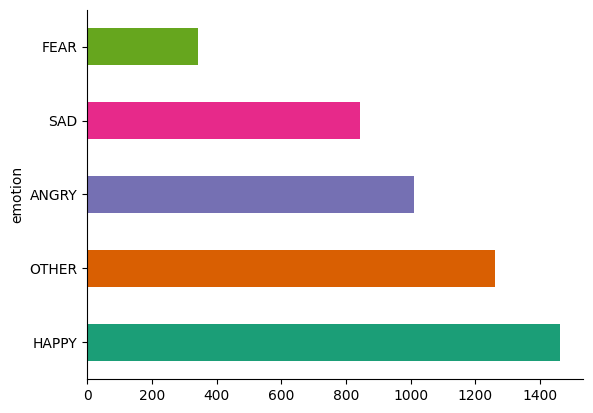

In [10]:
df_train['emotion'].value_counts().plot(kind='barh', color=sns.color_palette('Dark2'))
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

Normalize text and clean:

In [11]:
normalizer = Normalizer()
tokenizer = WordTokenizer()
lemmatizer = Lemmatizer()
stemmer = Stemmer()

In [12]:
stop_words = [
    'و', 'در', 'به', 'از', 'كه', 'مي', 'اين', 'است', 'را', 'با', 'هاي', 'براي', 'آن', 'يك',
    'شود', 'شده', 'خود', 'ها', 'كرد', 'شد', 'اي', 'تا', 'كند', 'بر', 'بود', 'گفت', 'نيز',
    'وي', 'هم', 'كنند', 'دارد', 'ما', 'كرده', 'يا', 'اما', 'بايد', 'دو', 'اند', 'هر',
    'خواهد', 'او', 'مورد', 'آنها', 'باشد', 'ديگر', 'مردم', 'نمي', 'بين', 'پيش', 'پس',
    'اگر', 'همه', 'صورت', 'يكي', 'هستند', 'بي', 'من', 'دهد', 'هزار', 'نيست', 'استفاده',
    'داد', 'داشته', 'راه', 'داشت', 'چه', 'همچنين', 'كردند', 'داده', 'بوده', 'دارند',
    'همين', 'ميليون', 'سوي', 'شوند', 'بيشتر', 'بسيار', 'روي', 'گرفته', 'هايي', 'تواند',
    'اول', 'نام', 'هيچ', 'چند', 'جديد', 'بيش', 'شدن', 'كردن', 'كنيم', 'نشان', 'حتي',
    'اينكه', 'ولی', 'توسط', 'چنين', 'برخي', 'نه', 'ديروز', 'دوم', 'درباره', 'بعد', 'مختلف',
    'گيرد', 'شما', 'گفته', 'آنان', 'بار', 'طور', 'گرفت', 'دهند', 'گذاري', 'بسياري', 'طي',
    'بودند', 'ميليارد', 'بدون', 'تمام', 'كل', 'تر', 'براساس', 'شدند', 'ترين', 'امروز',
    'باشند', 'ندارد', 'چون', 'قابل', 'گويد', 'ديگري', 'همان', 'خواهند', 'قبل', 'آمده',
    'اكنون', 'تحت', 'طريق', 'گيري', 'جاي', 'هنوز', 'چرا', 'البته', 'كنيد', 'سازي', 'سوم',
    'كنم', 'بلكه', 'زير', 'توانند', 'ضمن', 'فقط', 'بودن', 'حق', 'آيد', 'وقتي', 'اش',
    'يابد', 'نخستين', 'مقابل', 'خدمات', 'امسال', 'تاكنون', 'مانند', 'تازه', 'آورد', 'فكر',
    'آنچه', 'نخست', 'نشده', 'شايد', 'چهار', 'جريان', 'پنج', 'ساخته', 'زيرا', 'نزديك',
    'برداري', 'كسي', 'ريزي', 'رفت', 'گردد', 'مثل', 'آمد', 'ام', 'بهترين', 'دانست',
    'كمتر', 'دادن', 'تمامي', 'جلوگيري', 'بيشتري', 'ايم', 'ناشي', 'چيزي', 'آنكه', 'بالا',
    'بنابراين', 'ايشان', 'بعضي', 'دادند', 'داشتند', 'برخوردار', 'نخواهد', 'هنگام', 'نبايد',
    'غير', 'نبود', 'ديده', 'وگو', 'داريم', 'چگونه', 'بندي', 'خواست', 'فوق', 'ده', 'نوعي',
    'هستيم', 'ديگران', 'همچنان', 'سراسر', 'ندارند', 'گروهي', 'سعي', 'روزهاي', 'آنجا',
    'يكديگر', 'كردم', 'بيست', 'بروز', 'سپس', 'رفته', 'آورده', 'نمايد', 'باشيم', 'گويند',
    'زياد', 'خويش', 'همواره', 'گذاشته', 'شش', 'نداشته', 'شناسي', 'خواهيم', 'آباد', 'داشتن',
    'نظير', 'همچون', 'باره', 'نكرده', 'شان', 'سابق', 'هفت', 'دانند', 'جايي', 'بی', 'جز',
    'زیرِ', 'رویِ', 'سریِ', 'تویِ', 'جلویِ', 'پیشِ', 'عقبِ', 'بالایِ', 'خارجِ', 'وسطِ',
    'بیرونِ', 'سویِ', 'کنارِ', 'پاعینِ', 'نزدِ', 'نزدیکِ', 'دنبالِ', 'حدودِ', 'برابرِ',
    'طبقِ', 'مانندِ', 'ضدِّ', 'هنگامِ', 'برایِ', 'مثلِ', 'بارة', 'اثرِ', 'تولِ', 'علّتِ',
    'سمتِ', 'عنوانِ', 'قصدِ', 'روب', 'جدا', 'کی', 'که', 'چیست', 'هست', 'کجا', 'کجاست',
    'کَی', 'چطور', 'کدام', 'آیا', 'مگر', 'چندین', 'یک', 'چیزی', 'دیگر', 'کسی', 'بعری',
    'هیچ', 'چیز', 'جا', 'کس', 'هرگز', 'یا', 'تنها', 'بلکه', 'بله', 'بلی', 'آره',
    'آری', 'مرسی', 'البتّه', 'لطفاً', 'ّه', 'انکه', 'وقتیکه', 'همین', 'پیش',
    'هنگامی', 'مان', 'تان'
]

In [13]:
def normalize_text(text):
    return normalizer.normalize(text)

In [14]:
def remove_urls_and_html(text):
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    return text

In [15]:
def clean_text(text):
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF]', '', text)
    return text

In [16]:
def tokenize_text(text):
    return tokenizer.tokenize(text)

In [17]:
def remove_stopwords(tokens):
    return [token for token in tokens if token not in stop_words and token.isalnum()]


In [18]:
def join_tokens(tokens):
    return ' '.join(tokens)

we have to combine datasets for preprocessing:

In [22]:
combined_df = pd.concat([df_train['text'], df_test['text']], axis=0).reset_index(drop=True)
combined_df = pd.DataFrame(combined_df, columns=['text'])

preproceesing:

In [23]:
combined_df['cleaned_text'] = combined_df['text'].apply(normalize_text)
combined_df['cleaned_text'] = combined_df['cleaned_text'].apply(remove_urls_and_html)
combined_df['cleaned_text'] = combined_df['cleaned_text'].apply(clean_text)
combined_df['cleaned_text'] = combined_df['cleaned_text'].apply(tokenize_text)
combined_df['cleaned_text'] = combined_df['cleaned_text'].apply(remove_stopwords)
combined_df['cleaned_text'] = combined_df['cleaned_text'].apply(join_tokens)

we use TF-IDF for feature extraction:

In [24]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_df=0.9, min_df=5, max_features=10000)
tfidf_features = tfidf_vectorizer.fit_transform(combined_df['cleaned_text'])

In [25]:
combined_df.head()

,text,cleaned_text
0,عکسی که چند روز پیش گذاشته بودم این فیلم الانش...,عکسی روز این فیلم الانشه وسط کوهها لابه لای مه...
1,تنهاییم شبیه تنهاییه ظهرای بچگیم شده وقتی که ه...,تنهاییم شبیه تنهاییه ظهرای بچگیم میخوابیدن خوا...
2,خوبه تمام قسمت‌های گوشی رو محافظت می‌کنه,خوبه قسمتهای گوشی رو محافظت میکنه
3,این خاک مال مردمان است نه حاکمان #ایران #مهسا_...,این خاکمال مردمان حاکمان ایران
4,اگه تو بغلت بودم حالم خیلی بهتر میشد,اگه تو بغلت بودم حالم خیلی بهتر میشد


we have to seperate the features for training and test sets:

In [26]:
X_train_features = tfidf_features[:len(df_train)]
X_test_features = tfidf_features[len(df_train):]

verify the shape of the training features

In [27]:
print(X_train_features.shape)

(4923, 1903)


to encode labels:

In [28]:
label_encoder = LabelEncoder()
y_train_labels = label_encoder.fit_transform(df_train['emotion'])

we have to map encoded labels to emotions:

In [29]:
class_mapping = {index: label for index, label in enumerate(label_encoder.classes_)}
print("Class Mapping:", class_mapping)
print("Transformed Labels:", y_train_labels)

Class Mapping: {0: 'ANGRY', 1: 'FEAR', 2: 'HAPPY', 3: 'OTHER', 4: 'SAD'}
Transformed Labels: [3 4 2 ... 4 3 4]


here we split the data into training and validation sets:

In [30]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train_features, y_train_labels, test_size=0.2, random_state=42)

2. Tree-based Classification Algorithms

functions to evaluate our model

In [31]:
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    precision = precision_score(y_true, y_pred, average='weighted')

    print(f"Metrics for {model_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Classification Report:\n{classification_report(y_true, y_pred, target_names=label_encoder.classes_)}\n")

Decision Tree Classifier:

In [32]:
param_grid_decision_tree = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['auto', 'sqrt']
}

In [33]:
seed = 10

In [34]:
decision_tree = DecisionTreeClassifier(random_state=seed)
grid_search_decision_tree = GridSearchCV(decision_tree, param_grid_decision_tree, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_decision_tree.fit(X_train, y_train)
best_decision_tree = grid_search_decision_tree.best_estimator_

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(


to evaluate our decision tree:

In [35]:
y_pred_decision_tree = best_decision_tree.predict(X_valid)
evaluate_model(y_valid, y_pred_decision_tree, 'Decision Tree')

Metrics for Decision Tree:
Accuracy: 0.5482
F1 Score: 0.5479
Recall: 0.5482
Precision: 0.5538
Classification Report:
              precision    recall  f1-score   support

       ANGRY       0.49      0.48      0.49       185
        FEAR       0.33      0.41      0.37        66
       HAPPY       0.76      0.73      0.74       306
       OTHER       0.47      0.55      0.51       267
         SAD       0.46      0.33      0.38       161

    accuracy                           0.55       985
   macro avg       0.50      0.50      0.50       985
weighted avg       0.55      0.55      0.55       985




Random Forest Classifier:

In [36]:
param_grid_random_forest = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

In [37]:
random_forest = RandomForestClassifier(random_state=seed)
grid_search_random_forest = GridSearchCV(random_forest, param_grid_random_forest, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_random_forest.fit(X_train, y_train)
best_random_forest = grid_search_random_forest.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits


to evaluate random forest model:

In [38]:
y_pred_random_forest = best_random_forest.predict(X_valid)
evaluate_model(y_valid, y_pred_random_forest, 'Random Forest')

Metrics for Random Forest:
Accuracy: 0.5949
F1 Score: 0.5930
Recall: 0.5949
Precision: 0.6037
Classification Report:
              precision    recall  f1-score   support

       ANGRY       0.51      0.41      0.45       185
        FEAR       0.62      0.52      0.56        66
       HAPPY       0.79      0.78      0.79       306
       OTHER       0.47      0.64      0.54       267
         SAD       0.56      0.43      0.49       161

    accuracy                           0.59       985
   macro avg       0.59      0.55      0.57       985
weighted avg       0.60      0.59      0.59       985




Gradient Boosting Classifier

In [39]:
param_grid_gradient_boosting = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [40]:
gradient_boosting = GradientBoostingClassifier(random_state=10)
grid_search_gradient_boosting = GridSearchCV(gradient_boosting, param_grid_gradient_boosting, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_gradient_boosting.fit(X_train, y_train)
best_gradient_boosting = grid_search_gradient_boosting.best_estimator_

Fitting 3 folds for each of 64 candidates, totalling 192 fits


to evaluate gradient boosting:

In [41]:
y_pred_gradient_boosting = best_gradient_boosting.predict(X_valid)
evaluate_model(y_valid, y_pred_gradient_boosting, 'Gradient Boosting')

Metrics for Gradient Boosting:
Accuracy: 0.5919
F1 Score: 0.5916
Recall: 0.5919
Precision: 0.6035
Classification Report:
              precision    recall  f1-score   support

       ANGRY       0.53      0.45      0.49       185
        FEAR       0.56      0.52      0.54        66
       HAPPY       0.81      0.77      0.79       306
       OTHER       0.46      0.62      0.53       267
         SAD       0.55      0.40      0.46       161

    accuracy                           0.59       985
   macro avg       0.58      0.55      0.56       985
weighted avg       0.60      0.59      0.59       985




XGBoost Classifier

In [42]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


In [43]:
xgboost = xgb.XGBClassifier(random_state=seed)
grid_search_xgb = GridSearchCV(xgboost, param_grid_xgb, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_xgb.fit(X_train, y_train)
best_xgb = grid_search_xgb.best_estimator_


Fitting 3 folds for each of 32 candidates, totalling 96 fits


to evaluate XGBoost:

In [44]:
y_pred_xgb = best_xgb.predict(X_valid)
evaluate_model(y_valid, y_pred_xgb, 'XGBoost')

Metrics for XGBoost:
Accuracy: 0.5990
F1 Score: 0.5989
Recall: 0.5990
Precision: 0.6224
Classification Report:
              precision    recall  f1-score   support

       ANGRY       0.56      0.46      0.51       185
        FEAR       0.57      0.53      0.55        66
       HAPPY       0.83      0.75      0.79       306
       OTHER       0.46      0.68      0.55       267
         SAD       0.59      0.36      0.45       161

    accuracy                           0.60       985
   macro avg       0.60      0.56      0.57       985
weighted avg       0.62      0.60      0.60       985




3. Model Evaluation on Test Data

first we use logistic regression

In [45]:
logistic_regression_pipeline = Pipeline([
    ('clf', LogisticRegression(max_iter=1000))
])
cv_scores_lr = cross_val_score(logistic_regression_pipeline, X_train_features, y_train_labels, cv=5, scoring='accuracy')

print(f'Logistic Regression - Accuracy: {cv_scores_lr.max() * 100:.2f}%')
print(f'Logistic Regression - Standard deviation: {cv_scores_lr.std() * 100:.2f}%')

Logistic Regression - Accuracy: 62.13%
Logistic Regression - Standard deviation: 1.60%


then we use support vector classifier model:

In [46]:
svc_pipeline = Pipeline([
    ('clf', SVC(probability=True))
])
cv_scores_svc = cross_val_score(svc_pipeline, X_train_features, y_train_labels, cv=5, scoring='accuracy')

print(f'SVC - Accuracy: {cv_scores_svc.max() * 100:.2f}%')
print(f'SVC - Standard deviation: {cv_scores_svc.std() * 100:.2f}%')

SVC - Accuracy: 62.64%
SVC - Standard deviation: 1.44%


after that we use ensemble model

In [47]:
logistic_regression = LogisticRegression(max_iter=1000)
svc = SVC(probability=True)

ensemble_classifier = VotingClassifier(
    estimators=[
        ('lr', logistic_regression),
        ('svc', svc)
    ],
    voting='soft'
)

ensemble_pipeline = Pipeline([
    ('clf', ensemble_classifier)
])

param_grid_ensemble = {
    'clf__lr__C': [0.1, 1],
    'clf__lr__solver': ['lbfgs'],
    'clf__svc__C': [1, 10],
    'clf__svc__kernel': ['linear', 'rbf'],
    'clf__svc__gamma': ['scale']
}

grid_search_ensemble = GridSearchCV(ensemble_pipeline, param_grid_ensemble, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_ensemble.fit(X_train_features, y_train_labels)
best_ensemble = grid_search_ensemble.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits


In [48]:
cv_scores_ensemble = cross_val_score(best_ensemble, X_train_features, y_train_labels, cv=5, scoring='accuracy')
print(f'Ensemble - Accuracy: {cv_scores_ensemble.max() * 100:.2f}%')
print(f'Ensemble - Standard deviation: {cv_scores_ensemble.std() * 100:.2f}%')

Ensemble - Accuracy: 62.44%
Ensemble - Standard deviation: 1.45%


4. predic on test data:


In [49]:
y_test_predictions = best_ensemble.predict(X_test_features)

In [58]:
label_to_emotion = {0: 'ANGRY', 1: 'FEAR', 2: 'HAPPY', 3: 'OTHER', 4: 'SAD'}
y_test_predictions_mapped = pd.DataFrame({'predicted_label': y_test_predictions})
df_test['Y'] = y_test_predictions_mapped['predicted_label'].map(label_to_emotion)

In [59]:
df_test.to_csv('/content/output.csv', index=False)